## Import libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Load the Dataset

In [3]:
df = pd.read_csv("movies.csv") 

### 1. How big is the data?

In [4]:
df.shape

(4000, 15)

### 2. How does the data look like?

In [5]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,"
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772.0,Warner Bros.,"146.0,"
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106.0,Columbia Pictures,"104.0,"
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067.0,Lucasfilm,"124.0,"
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539.0,Paramount Pictures,"88.0,"
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344.0,Orion Pictures,"98.0,"


In [6]:
df.sample(5)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,"
1369,Stealing Home,PG-13,Drama,1988,"August 26, 1988 (United States)",6.7,4200,Steven Kampmann,Steven Kampmann,Mark Harmon,United States,0,7467504.0,The Mount Company,"98.0,"
2977,If Lucy Fell,R,Comedy,1996,"March 8, 1996 (United States)",4.9,3800,Eric Schaeffer,Eric Schaeffer,Sarah Jessica Parker,United States,5000000,2420162.0,Motion Picture Corporation of America (MPCA),"92.0,"
3292,The Horse Whisperer,PG-13,Drama,1998,"May 15, 1998 (United States)",6.6,40000,Robert Redford,Nick Evans,Robert Redford,United States,60000000,186883563.0,Touchstone Pictures,"169.0,"
270,My Favorite Year,PG,Comedy,1982,"October 8, 1982 (United States)",7.4,9000,Richard Benjamin,Norman Steinberg,Peter O'Toole,United States,0,20123620.0,Metro-Goldwyn-Mayer (MGM),"92.0,"
1821,Lambada,PG,Drama,1990,"March 16, 1990 (United States)",3.5,979,Joel Silberg,Joel Silberg,J. Eddie Peck,United States,0,4263112.0,Cannon Films,"104.0,"


### 3. What is the datatype of cols?

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       4000 non-null   object 
 1   rating     3960 non-null   object 
 2   genre      4000 non-null   object 
 3   year       4000 non-null   int64  
 4   released   4000 non-null   object 
 5   score      4000 non-null   float64
 6   votes      4000 non-null   int64  
 7   director   4000 non-null   object 
 8   writer     3999 non-null   object 
 9   star       3999 non-null   object 
 10  country    4000 non-null   object 
 11  budget     4000 non-null   int64  
 12  gross      3831 non-null   float64
 13  company    3990 non-null   object 
 14  runtime,,  4000 non-null   object 
dtypes: float64(2), int64(3), object(10)
memory usage: 468.9+ KB


### 4. Are there any missing values?


In [8]:
df.isnull().sum()

name           0
rating        40
genre          0
year           0
released       0
score          0
votes          0
director       0
writer         1
star           1
country        0
budget         0
gross        169
company       10
runtime,,      0
dtype: int64

### 5. How does the data look mathematically?

In [9]:
df.describe()

,year,score,votes,budget,gross
count,4000.000000,4000.000000,4.000000e+03,4.000000e+03,3.831000e+03
mean,1991.191500,6.321950,5.449450e+04,1.542740e+07,4.172202e+07
std,5.934529,0.977101,1.427738e+05,2.248639e+07,9.259504e+07
min,1980.000000,2.200000,5.100000e+01,0.000000e+00,3.090000e+02
25%,1986.000000,5.700000,4.300000e+03,0.000000e+00,2.835743e+06
50%,1991.000000,6.400000,1.300000e+04,7.000000e+06,1.183822e+07
75%,1996.000000,7.000000,4.500000e+04,2.100000e+07,3.560495e+07
max,2001.000000,9.300000,2.400000e+06,2.000000e+08,2.201647e+09


### 6. Are there duplicate values?

In [10]:
df.duplicated().sum()

0

In [11]:
df.corr(numeric_only = True)['score']

year      0.083777
score     1.000000
votes     0.387401
budget    0.028239
gross     0.207526
Name: score, dtype: float64

# I. Univariate Analysis (Individual Variables)

## a. Categorical Data

### Q1. What are the most common movie genres (genre)?


<Axes: xlabel='genre'>

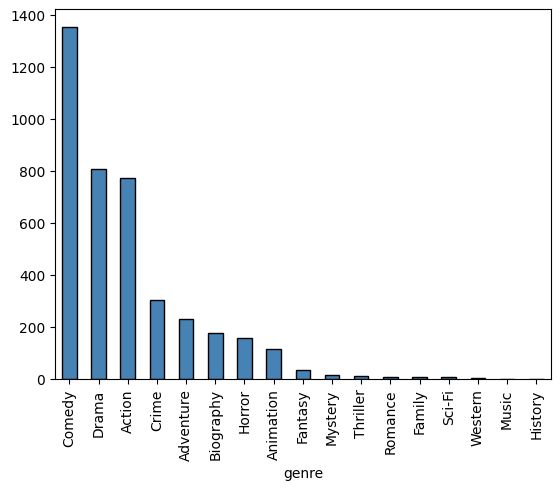

In [12]:
df['genre'].value_counts().plot(kind="bar", color="steelblue", edgecolor= "black")

### Q2. What is the breakdown of content ratings (rating)?


<Axes: ylabel='count'>

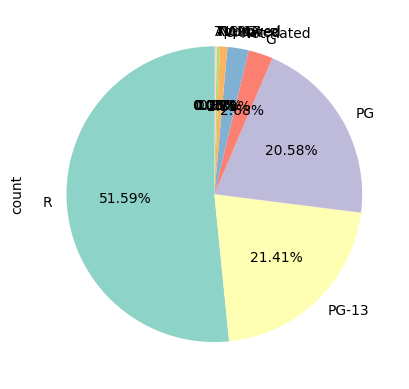

In [ ]:
df['rating'].value_counts().plot(
    kind='pie',
    autopct='%.2f%%',
    startangle=90,
    colors=plt.cm.Set3.colors
)

### Q3. Which countries produce the most movies (country)?

<Axes: xlabel='country'>

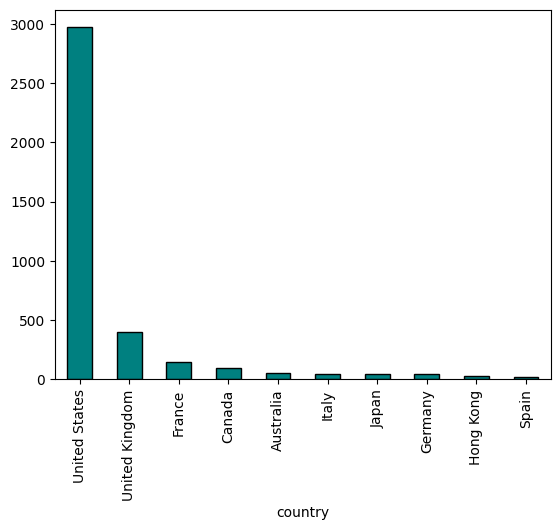

In [13]:
df['country'].value_counts().head(10).plot(kind= 'bar', color= 'teal', edgecolor= "black")

### Q4. Which production companies (company) appear most frequently?

<Axes: ylabel='company'>

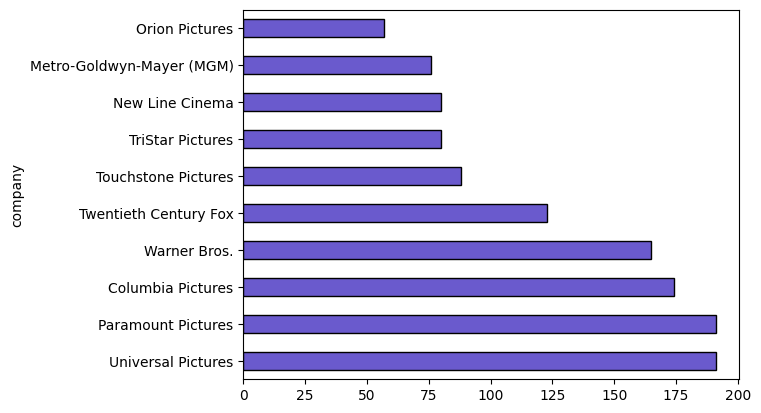

In [14]:
df['company'].value_counts().head(10).plot(kind= 'barh', color= "slateblue", edgecolor= "black")

### Q5. How many movies were released each year between 1980 and 2001?


<Axes: xlabel='year'>

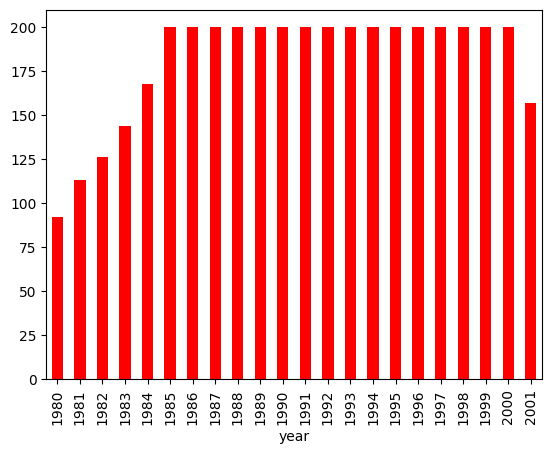

In [15]:
df['year'].value_counts().sort_index().plot(
    kind='bar',
    color='red',)

## Numerical Columns

### Q6. What is the distribution of IMDb scores (score)?


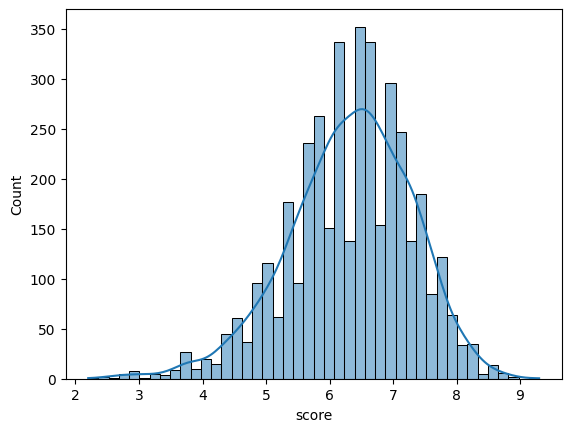

In [16]:
sns.histplot(df['score'], kde= True)
plt.show()


### Q7. How are movie budgets (budget) distributed?

(array([1.961e+03, 5.530e+02, 3.820e+02, 3.370e+02, 1.920e+02, 9.700e+01,
        1.200e+02, 7.200e+01, 3.900e+01, 6.800e+01, 3.600e+01, 2.400e+01,
        3.800e+01, 2.800e+01, 7.000e+00, 1.600e+01, 3.000e+00, 6.000e+00,
        6.000e+00, 4.000e+00, 2.000e+00, 4.000e+00, 0.000e+00, 0.000e+00,
        2.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([0.00000000e+00, 6.66666667e+06, 1.33333333e+07, 2.00000000e+07,
        2.66666667e+07, 3.33333333e+07, 4.00000000e+07, 4.66666667e+07,
        5.33333333e+07, 6.00000000e+07, 6.66666667e+07, 7.33333333e+07,
        8.00000000e+07, 8.66666667e+07, 9.33333333e+07, 1.00000000e+08,
        1.06666667e+08, 1.13333333e+08, 1.20000000e+08, 1.26666667e+08,
        1.33333333e+08, 1.40000000e+08, 1.46666667e+08, 1.53333333e+08,
        1.60000000e+08, 1.66666667e+08, 1.73333333e+08, 1.80000000e+08,
        1.86666667e+08, 1.93333333e+08, 2.00000000e+08]),
 <BarContainer object of 30 artists>)

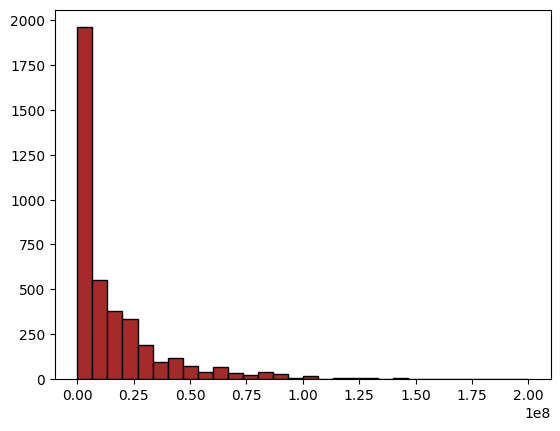

In [25]:
budget_clean = df[df['budget'] > 0]['budget']
plt.hist(df['budget'],bins= 30, color= 'brown', edgecolor= 'black')

### Q8. What does the gross revenue (gross) distribution look like?

(array([3.289e+03, 2.490e+02, 1.240e+02, 6.200e+01, 5.600e+01, 1.600e+01,
        1.800e+01, 5.000e+00, 2.000e+00, 2.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 2.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([3.09000000e+02, 7.33885408e+07, 1.46776773e+08, 2.20165004e+08,
        2.93553236e+08, 3.66941468e+08, 4.40329700e+08, 5.13717932e+08,
        5.87106164e+08, 6.60494396e+08, 7.33882627e+08, 8.07270859e+08,
        8.80659091e+08, 9.54047323e+08, 1.02743555e+09, 1.10082379e+09,
        1.17421202e+09, 1.24760025e+09, 1.32098848e+09, 1.39437671e+09,
        1.46776495e+09, 1.54115318e+09, 1.61454141e+09, 1.68792964e+09,
        1.76131787e+09, 1.83470610e+09, 1.90809434e+09, 1.98148257e+09,
        2.05487080e+09, 2.12825903e+09, 2.20164726e+09]),
 <BarContainer object of 30 artists>)

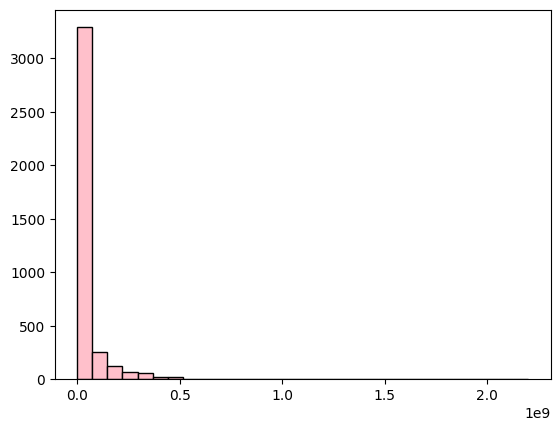

In [26]:
gross_clean = df[df["gross"] > 0]["gross"]
plt.hist(df["gross"], bins = 30, color ="pink", edgecolor="black")

### Q9. How are the number of votes (votes) distributed on IMDb?


(array([3.383e+03, 3.040e+02, 1.300e+02, 6.800e+01, 3.500e+01, 1.100e+01,
        1.100e+01, 6.000e+00, 9.000e+00, 6.000e+00, 4.000e+00, 7.000e+00,
        6.000e+00, 6.000e+00, 4.000e+00, 0.000e+00, 2.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 3.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([5.1000000e+01, 8.0049300e+04, 1.6004760e+05, 2.4004590e+05,
        3.2004420e+05, 4.0004250e+05, 4.8004080e+05, 5.6003910e+05,
        6.4003740e+05, 7.2003570e+05, 8.0003400e+05, 8.8003230e+05,
        9.6003060e+05, 1.0400289e+06, 1.1200272e+06, 1.2000255e+06,
        1.2800238e+06, 1.3600221e+06, 1.4400204e+06, 1.5200187e+06,
        1.6000170e+06, 1.6800153e+06, 1.7600136e+06, 1.8400119e+06,
        1.9200102e+06, 2.0000085e+06, 2.0800068e+06, 2.1600051e+06,
        2.2400034e+06, 2.3200017e+06, 2.4000000e+06]),
 <BarContainer object of 30 artists>)

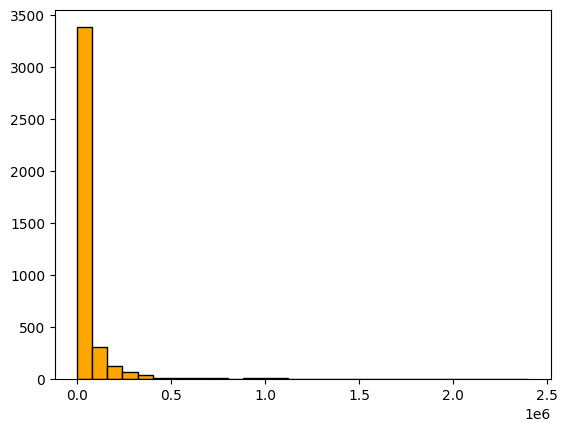

In [31]:
plt.hist(df["votes"], bins=30, color="orange", edgecolor="black")

### Q10. What is the distribution of movie runtimes (runtime)?

In [39]:
df.columns = df.columns.str.strip().str.replace(',', '')

(array([456., 311., 342., 343., 477., 387., 246., 204., 398., 200., 200.,
         81.,  56.,  49.,  35.,  34.,  24.,  10.,  22.,  31.,  15.,  10.,
          8.,  12.,   6.,   8.,  11.,   8.,   8.,   8.]),
 array([  0. ,   5.6,  11.2,  16.8,  22.4,  28. ,  33.6,  39.2,  44.8,
         50.4,  56. ,  61.6,  67.2,  72.8,  78.4,  84. ,  89.6,  95.2,
        100.8, 106.4, 112. , 117.6, 123.2, 128.8, 134.4, 140. , 145.6,
        151.2, 156.8, 162.4, 168. ]),
 <BarContainer object of 30 artists>)

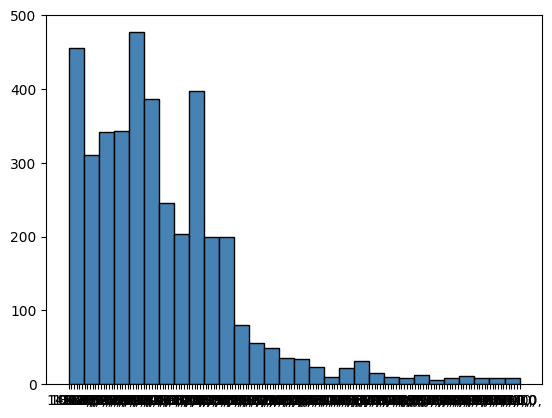

In [40]:
plt.hist(df["runtime"], bins=30, color="steelblue", edgecolor="black")